In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, f1_score


from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    average_precision_score,
    PrecisionRecallDisplay
)

In [50]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style = "whitegrid")

df = pd.read_csv(
    "../data/processed/loan_2018q2_clean.csv",
    parse_dates=["issue_d", "earliest_cr_line"],
    low_memory=False
)


##### Class balance

In [51]:
df["non_performing"].value_counts(normalize=True).mul(100).round(2)


non_performing
0   96.27
1    3.73
Name: proportion, dtype: float64

##### Class balance observation

The target is highly imbalanced: only about 3.7% of loans are non-performing. Because of this, accuracy is not a reliable model-quality metric. A model that predicts every loan as performing would have about 96% accuracy, so model quality should be judged mainly using recall, precision, F1-score, ROC AUC, Average Precision, and the confusion matrix.


##### Target Creation

In [52]:
npl_statuses = [
    "Late (16-30 days)",
    "Late (31-120 days)",
    "Default",
    "Charged Off"
]

df["target_npl"] = df["loan_status"].isin(npl_statuses).astype(int)
df["target_npl"].value_counts(normalize=True).mul(100).round(2)

target_npl
0   96.27
1    3.73
Name: proportion, dtype: float64

##### Features

The model includes engineered missingness flags created during cleaning and interaction features that test combined affordability, priced-risk, and credit-stress effects.


In [53]:
numeric_features = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "emp_length",
    "revol_util",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "total_acc",
    "credit_history_months",
    "loan_to_income",
    "installment_to_income_pct",
    "dti_after_loan",
    "income_buffer_pct",
    "revol_bal_to_income",
    "total_bal_ex_mort_to_income",
    "loan_to_total_credit_limit",
    "int_rate_x_loan_to_income",
    "int_rate_x_installment_income",
    "loan_to_income_x_dti",
    "inq_x_delinq",
    "revol_util_x_dti",
    "zero_income_flag",
    "high_dti_flag",
    "has_joint_app_info",
    "has_last_record",
    "has_recent_bc_dlq",
    "has_last_major_derog",
    "has_recent_revol_delinq",
    "has_last_delinq"
]

categorical_features = [
    "grade",
    "sub_grade",
    "verification_status",
    "home_ownership",
    "purpose",
    "application_type"
]


In [54]:
df = df[df["home_ownership"] != "ANY"]

In [55]:
features = numeric_features + categorical_features

X = df[features]
y = df["target_npl"]

##### Preprocessing

In [83]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [84]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))
])

##### Training

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

##### Modeling approach observation

Logistic Regression was selected as the final model because it provides a clear and explainable baseline for predicting non-performing loans. The train-test split is stratified so that the rare non-performing class has a similar proportion in both training and test data. `class_weight="balanced"` is used to reduce the impact of class imbalance during model training.


##### Results

In [86]:
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()
coefficients = classifier.coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
}).sort_values("abs_coefficient", ascending=False)

In [87]:
y_proba = model.predict_proba(X_test)[:, 1]

threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)



              precision    recall  f1-score   support

           0       0.98      0.65      0.78     25176
           1       0.07      0.67      0.12       976

    accuracy                           0.65     26152
   macro avg       0.52      0.66      0.45     26152
weighted avg       0.95      0.65      0.76     26152

ROC AUC: 0.720792587397834
Average Precision: 0.09488306053656527
[[16309  8867]
 [  320   656]]


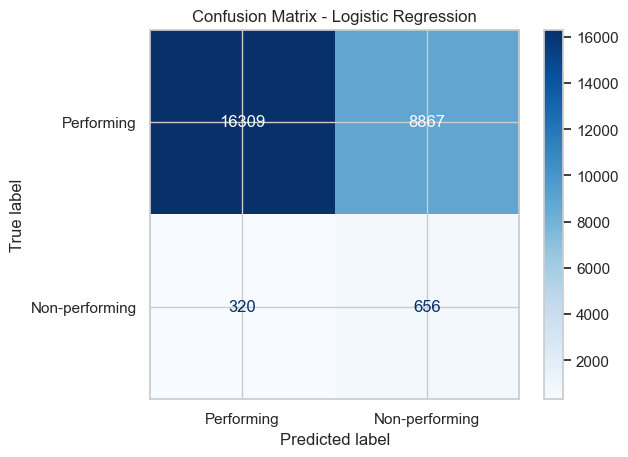

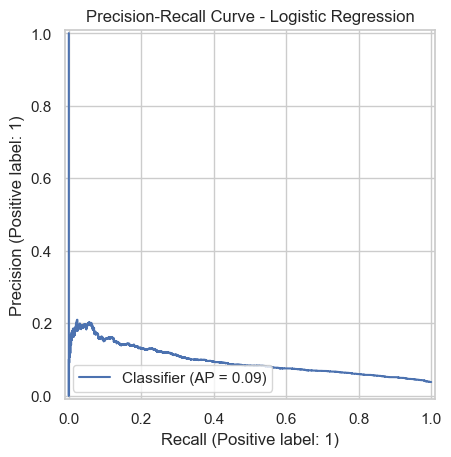

,feature,coefficient,abs_coefficient
76,cat__verification_status_Source Verified,0.26,0.26
61,cat__sub_grade_E1,-0.26,0.26
82,cat__purpose_credit_card,-0.27,0.27
50,cat__sub_grade_B5,0.28,0.28
53,cat__sub_grade_C3,-0.29,0.29
44,cat__sub_grade_A4,-0.30,0.30
67,cat__sub_grade_F2,0.30,0.30
5,num__dti,-0.30,0.30
80,cat__home_ownership_RENT,0.32,0.32
79,cat__home_ownership_OWN,0.34,0.34


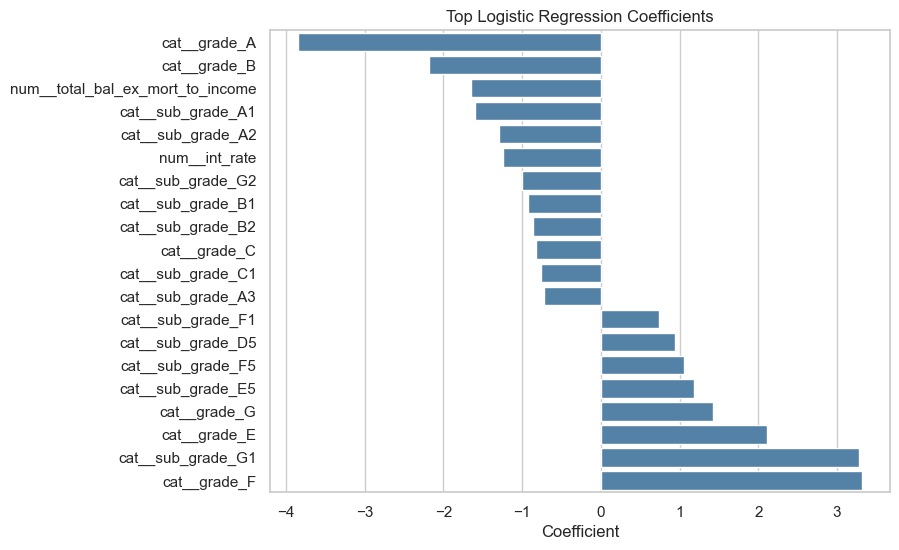

In [88]:
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Average Precision:", average_precision_score(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Performing", "Non-performing"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba
)

plt.title("Precision-Recall Curve - Logistic Regression")
plt.show()

display(feature_importance.head(50).round(2).sort_values("abs_coefficient"))
top_features = feature_importance.head(20).sort_values("coefficient")

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_features,
    x="coefficient",
    y="feature",
    color="steelblue"
)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("")
plt.show()


##### Results interpretation

At the selected threshold of 0.50, the model identifies a meaningful share of non-performing loans, with recall around 0.68 for the non-performing class. Precision remains low, around 0.07, meaning many loans flagged as risky are still performing. This is expected because non-performing loans are rare in the dataset.

ROC AUC is around 0.72, which suggests moderate ability to rank loans by non-performing risk. Average Precision is around 0.10, which is low but meaningfully above the baseline non-performing rate of about 3.7%.

The confusion matrix shows the main practical tradeoff: the model catches many non-performing loans, but also produces many false positives. Therefore, this model is better suited as a risk-screening or early-warning tool than as an automatic loan decision model.

The coefficient table and chart indicate that grade, sub-grade, interest rate and debt-related variables are among the strongest predictors of non-performing loans. This is consistent with the exploratory analysis, where borrowers with higher borrowing costs and greater debt burden exhibited higher non-performing rates.
Some categories, such as home_ownership=ANY, received large coefficients but sample size was very small and therefore should not be treated as reliable business signals.

##### Model experiments and final choice

Several variations were tested before choosing the final model. Logistic Regression and XGBoost produced very similar ROC-AUC and Average Precision scores. Logistic Regression was therefore selected as the final model due to its simplicity, interpretability, and comparable predictive performance.

Different probability thresholds were also evaluated. Lower thresholds increased recall at the cost of substantially more false positives, while higher thresholds improved precision but missed a larger proportion of non-performing loans. This demonstrates the importance of threshold selection based on business objectives.

Models with and without `int_rate`, `grade`, and `sub_grade` were tested. Keeping these lender risk indicators improved predictive performance, but they should be interpreted carefully because they contain overlapping risk information. Additional feature and parameter experiments, including the engineered flags and missing-value indicators, did not materially improve performance, so the final notebook keeps the model focused.


##### Final summary

The final Logistic Regression model successfully ranks loans by non-performing risk using borrower, loan, credit-history, and lender risk assessment variables. Because the base model uses `class_weight="balanced"`, its raw probabilities are not well calibrated, so a calibrated version is also evaluated for probability interpretation.

The model achieved a ROC-AUC of approximately 0.72, indicating moderate discriminatory power and meaningful separation between performing and non-performing loans. Calibration does not materially change ranking metrics, but it brings predicted probabilities closer to observed NPL rates by risk decile.

The results suggest that loan pricing, grade assignment, and borrower debt burden are among the most informative indicators of future non-performance.

In practice, the model would be most valuable as a risk-screening tool to prioritize applications for further review rather than as a fully automated approval or rejection system.


##### Limitations

- The analysis uses data from a single quarter (2018 Q2), limiting the ability to evaluate performance stability across different economic conditions.
- The target variable is highly imbalanced, with non-performing loans representing only a small fraction of observations.
- Several predictive variables, such as grade, sub-grade, and interest rate, already reflect LendingClub's internal risk assessment process and may partially overlap in the information they provide.

In [89]:
results = pd.DataFrame({
  "actual": y_test,
  "prob": y_proba
})

results["decile"] = pd.qcut(
  results["prob"],
  q=10,
  labels=False,
  duplicates="drop"
) + 1

decile_summary = (
  results
  .groupby("decile")
  .agg(
    loan_count=("actual", "size"),
    npl_count=("actual", "sum"),
    actual_npl_rate_pct=("actual", lambda x: x.mean() * 100),
    avg_predicted_prob_pct=("prob", lambda x: x.mean() * 100)
  )
  .round(2)
)

display(decile_summary)

decile_recall = (
  results
  .groupby("decile")
  .agg(
    loan_count=("actual", "size"),
    npl_count=("actual", "sum")
  )
  .assign(
    recall_pct=lambda x: x["npl_count"] / results["actual"].sum() * 100
  )
  .round(2)
)


display(decile_recall)

,loan_count,npl_count,actual_npl_rate_pct,avg_predicted_prob_pct
decile,,,,
1,2616,16,0.61,12.01
2,2615,28,1.07,19.91
3,2615,37,1.41,26.71
4,2615,53,2.03,33.04
5,2615,65,2.49,38.92
6,2615,76,2.91,44.78
7,2615,116,4.44,50.90
8,2615,140,5.35,57.48
9,2615,155,5.93,65.11


,loan_count,npl_count,recall_pct
decile,,,
1,2616,16,1.64
2,2615,28,2.87
3,2615,37,3.79
4,2615,53,5.43
5,2615,65,6.66
6,2615,76,7.79
7,2615,116,11.89
8,2615,140,14.34
9,2615,155,15.88


In [90]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    estimator=model,
    method="isotonic",  # or "sigmoid"
    cv=5
)

calibrated_model.fit(X_train, y_train)

calibrated_probs = calibrated_model.predict_proba(X_test)[:, 1]


def decile_analysis(y_true, probs):
    
    deciles = pd.DataFrame({
        "actual": y_true,
        "probability": probs
    })

    deciles["decile"] = pd.qcut(
        deciles["probability"],
        10,
        labels=False,
        duplicates="drop"
    ) + 1

    summary = (
        deciles
        .groupby("decile")
        .agg(
            count=("actual", "size"),
            avg_predicted_prob_pct=("probability", lambda x: x.mean() * 100),
            actual_default_rate_pct=("actual", lambda x: x.mean() * 100)
        )
        .round(3)
    )

    return summary

uncalibrated_deciles = decile_analysis(y_test, y_proba)
calibrated_deciles = decile_analysis(y_test, calibrated_probs)

display(uncalibrated_deciles)
display(calibrated_deciles)



,count,avg_predicted_prob_pct,actual_default_rate_pct
decile,,,
1,2616,12.01,0.61
2,2615,19.91,1.07
3,2615,26.71,1.42
4,2615,33.04,2.03
5,2615,38.92,2.49
6,2615,44.78,2.91
7,2615,50.90,4.44
8,2615,57.48,5.35
9,2615,65.11,5.93


,count,avg_predicted_prob_pct,actual_default_rate_pct
decile,,,
1,2640,0.49,0.64
2,2626,0.91,1.10
3,2580,1.36,1.36
4,2630,1.88,2.02
5,2900,2.64,2.45
6,2463,3.10,3.09
7,2633,3.96,4.48
8,2450,5.17,5.02
9,2615,7.19,6.42


In [91]:
calibrated_threshold = y_train.mean()
calibrated_pred = (calibrated_probs >= calibrated_threshold).astype(int)

print(f"Calibrated probability threshold: {calibrated_threshold:.3f}")
print(classification_report(y_test, calibrated_pred))
print("ROC AUC:", roc_auc_score(y_test, calibrated_probs))
print("Average Precision:", average_precision_score(y_test, calibrated_probs))
print(confusion_matrix(y_test, calibrated_pred))






Calibrated probability threshold: 0.037
              precision    recall  f1-score   support

           0       0.98      0.65      0.78     25176
           1       0.07      0.67      0.13       976

    accuracy                           0.65     26152
   macro avg       0.52      0.66      0.45     26152
weighted avg       0.95      0.65      0.76     26152

ROC AUC: 0.7204882748402069
Average Precision: 0.09394774905581597
[[16316  8860]
 [  319   657]]
